## **13. 결측치 대치 실험**
+ Air Quality 데이터를 활용하여 벤젠 농도 변수('C6H6(GT)')의 결측치를 다양한 기법으로 대치하고 성능을 비교
+ 의도적으로 30%의 결측치를 생성한 뒤, 원래의 값(Ground Truth)과 대치된 값 사이의 MAE(Mean Absolute Error)를 측정하여 어떤 기법이 가장 정교한지 분석

In [3]:
from datetime import datetime # Datetime 변환
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error # 대치 결과 정확도 평가
from sklearn.impute import KNNImputer # k-NN 대치 모델
from sklearn.experimental import enable_iterative_imputer # MICE 대치 모델
from sklearn.impute import IterativeImputer # MICE 대치 모델

### **1. 데이터 로드 및 시계열 인덱스 설정**

In [10]:
import pandas as pd
import os
from datetime import datetime

# String -> Datetime 파싱 함수
def parser(x):
    return datetime.strptime(x, '%Y-%m-%d %H:%M:%S')

# 데이터 파일
path = './data/'
filename = 'AirQualityUCI_refined.csv'

input_file = os.path.join(path, filename)

# 데이터 로드
df = pd.read_csv(
    input_file,
    index_col=0,
    parse_dates=[0],
    date_parser=parser
)

print(df.head())

                     CO(GT)  PT08.S1(CO)  PT08.S2(NMHC)  NOx(GT)  \
Datetime                                                           
2004-03-10 18:00:00     2.6       1360.0         1046.0    166.0   
2004-03-10 19:00:00     2.0       1292.0          955.0    103.0   
2004-03-10 20:00:00     2.2       1402.0          939.0    131.0   
2004-03-10 21:00:00     2.2       1376.0          948.0    172.0   
2004-03-10 22:00:00     1.6       1272.0          836.0    131.0   

                     PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)    RH  \
Datetime                                                                      
2004-03-10 18:00:00        1056.0    113.0        1692.0       1268.0  48.9   
2004-03-10 19:00:00        1174.0     92.0        1559.0        972.0  47.7   
2004-03-10 20:00:00        1140.0    114.0        1555.0       1074.0  54.0   
2004-03-10 21:00:00        1092.0    122.0        1584.0       1203.0  60.0   
2004-03-10 22:00:00        1205.0    116.0       

C:\Users\서영준\AppData\Local\Temp\ipykernel_20728\793037164.py:16: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(


In [44]:
# 대상 변수 설정 및 원본 보관
target_col = 'C6H6(GT)' # 벤젠 농도
original_values = df[target_col].copy()

### **2. 의도적 결측치 생성**
결측 비율: 30%

In [46]:
np.random.seed(42)

# 0~1 사이 난수를 생성하여 0.3보다 작은 위치를 True로 표시하는 마스크 생성
mask = np.random.rand(len(df)) < 0.3
df_missing = df.copy()

# [+] 마스크가 True인 위치의 target_col 값을 NaN으로 변경
df_missing.loc[mask, target_col] = np.nan

### **3. 다양한 결측치 대치 수행**
각 대치 기법의 특성에 맞는 Pandas/Scikit-learn 메서드를 사용

In [48]:
imputed_results = {} # 전체 대치 결과를 저장할 딕셔너리

In [50]:
# [1] 평균 대체 (Mean Imputation)
# fillna와 mean() 함수를 조합하여 작성하세요.
imputed_results['Mean'] = df_missing[target_col].fillna(
    df_missing[target_col].mean()
)

In [24]:
# [2] LOCF (Last Observation Carried Forward)
# LOCF로 데이터를 대체하는 코드 작성
imputed_results['LOCF'] = df_missing[target_col].fillna(
    method='ffill'
)

C:\Users\서영준\AppData\Local\Temp\ipykernel_20728\4041409634.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  imputed_results['LOCF'] = df_missing[target_col].fillna(


In [26]:
# [3] NOCB (Next Observation Carried Backward)
# NOCB로 데이터를 대체하는 코드 작성
imputed_results['NOCB'] = df_missing[target_col].fillna(
    method='bfill'
)

C:\Users\서영준\AppData\Local\Temp\ipykernel_20728\737130498.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  imputed_results['NOCB'] = df_missing[target_col].fillna(


In [28]:
# [4] 선형 보간 (Linear Interpolation)
# 선형 보간으로 데이터를 대체하는 코드 작성
imputed_results['Linear'] = df_missing[target_col].interpolate(
    method='linear'
)

In [30]:
# [5] 스플라인 보간 (Spline Interpolation)
# 3차 스플라인 보간으로 데이터를 대체하는 코드 작성
imputed_results['Spline'] = df_missing[target_col].interpolate(
    method='spline',
    order=3
)

In [34]:
from sklearn.impute import KNNImputer

# [6] k-NN 대치 (k-Nearest Neighbors)
knn_imputer = KNNImputer(n_neighbors=5)  # KNNImputer 객체 생성

knn_res = knn_imputer.fit_transform(df_missing)  # 학습 및 대치

imputed_results['k-NN'] = pd.Series(
    knn_res[:, df_missing.columns.get_loc(target_col)],
    index=df.index
)

In [35]:
# [7] MICE (Multivariate Imputation by Chained Equations)
mice_imputer = IterativeImputer(random_state=42) # [+] IterativeImputer = MICE 모델
mice_res = mice_imputer.fit_transform(df_missing) # [+] MICE 모델 학습 및 대치
imputed_results['MICE'] = pd.Series(
    mice_res[:, df_missing.columns.get_loc(target_col)], 
    index=df.index
)

C:\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### **4. 정확도(MAE) 측정**

In [38]:
from sklearn.metrics import mean_absolute_error

mae_scores = {}

for method, series in imputed_results.items():
    # 결측치가 생성된 지점만 골라서 MAE 오차 계산
    score = mean_absolute_error(
        original_values[mask],
        series[mask]
    )
    
    mae_scores[method] = score

## **5. 결과 시각화**

C:\Users\서영준\AppData\Local\Temp\ipykernel_20728\3558655479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mae_df.values, y=mae_df.index, palette='magma')


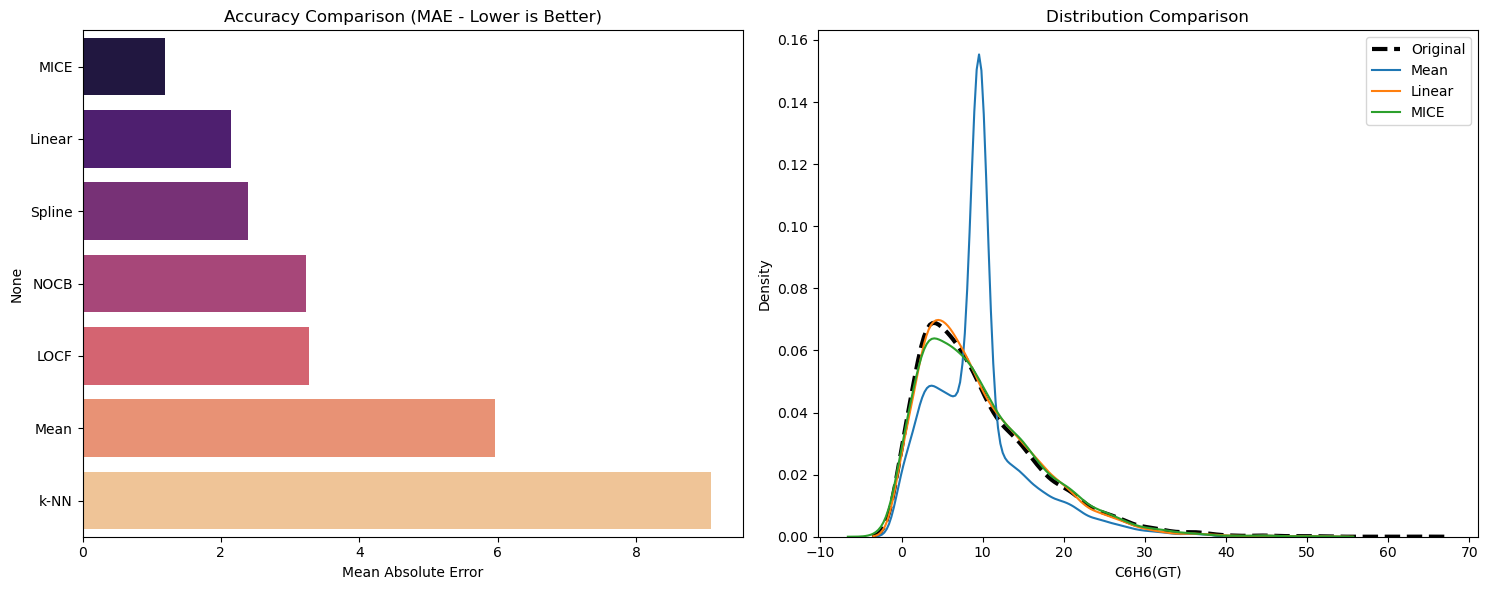

In [40]:
plt.figure(figsize=(15, 6))

# (A) MAE 비교 차트
plt.subplot(1, 2, 1)
mae_df = pd.Series(mae_scores).sort_values()
sns.barplot(x=mae_df.values, y=mae_df.index, palette='magma')
plt.title('Accuracy Comparison (MAE - Lower is Better)')
plt.xlabel('Mean Absolute Error')

# (B) 데이터 분포 비교 (KDE Plot)
plt.subplot(1, 2, 2)
sns.kdeplot(original_values, label='Original', color='black', lw=3, ls='--')
for method in ['Mean', 'Linear', 'MICE']: # 주요 기법만 시각화
    sns.kdeplot(imputed_results[method], label=method)
plt.title('Distribution Comparison')
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
# 상세 결과 출력
print("### Method-wise MAE Scores ###")
print(mae_df)

### Method-wise MAE Scores ###
MICE      1.185958
Linear    2.138718
Spline    2.385979
NOCB      3.225614
LOCF      3.279509
Mean      5.962172
k-NN      9.084185
dtype: float64


## **Discussion**
1. **시각화 해석**: 왜 Mean 대치의 분포(KDE)는 가운데가 뾰족하게 솟아올랐을까?
2. **데이터의 선형성**: 왜 단순한 선형 보간법이 MICE만큼이나 높은 정확도를 보였을까?
3. **실무적 함의**: "성능은 MICE가 제일 좋지만, 실시간 대량 데이터 처리 환경이라면 연산 속도가 빠른 LOCF나 Linear 중 무엇을 택해야 할까?"